# **Diff Operator — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.diff_operator import diffop
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [16]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [20]:
# Load one image (from disk if available, otherwise synthetic), then build runners

image = io.read_image(images_path[rand], framework="numpy")

function_selected = "sobel_hessian"  # choose function (gradient, laplacian, hessian, sobel, sobel_hessian, etc...)

def make_runner(diff_strategy, func=function_selected, input_format="numpy", output_format="numpy", backend="sequential"):
    @timer(return_result=True, name = func + "_" + diff_strategy)
    def _runner(img=image):
        return diffop(
            img, func=func, diff_strategy=diff_strategy,
            framework=input_format, output_format=output_format, backend=backend
        )
    return _runner

vectorized_ = make_runner("vectorized")
classic_    = make_runner("classic")
torch_      = make_runner("torch", input_format="torch")
parallel_   = make_runner("parallel", backend="sequential")

vectorized_res = vectorized_(image)
classic_res    = classic_(image)
torch_res      = torch_(image)
parallel_res   = parallel_(image)

print("Computed: vectorized, classic, torch, parallel.")

Execution time for 'sobel_hessian_vectorized': 1.404 seconds
Execution time for 'sobel_hessian_classic': 1.448 seconds
Execution time for 'sobel_hessian_torch': 1.636 seconds
Execution time for 'sobel_hessian_parallel': 1.334 seconds
Computed: vectorized, classic, torch, parallel.


## Visualisation

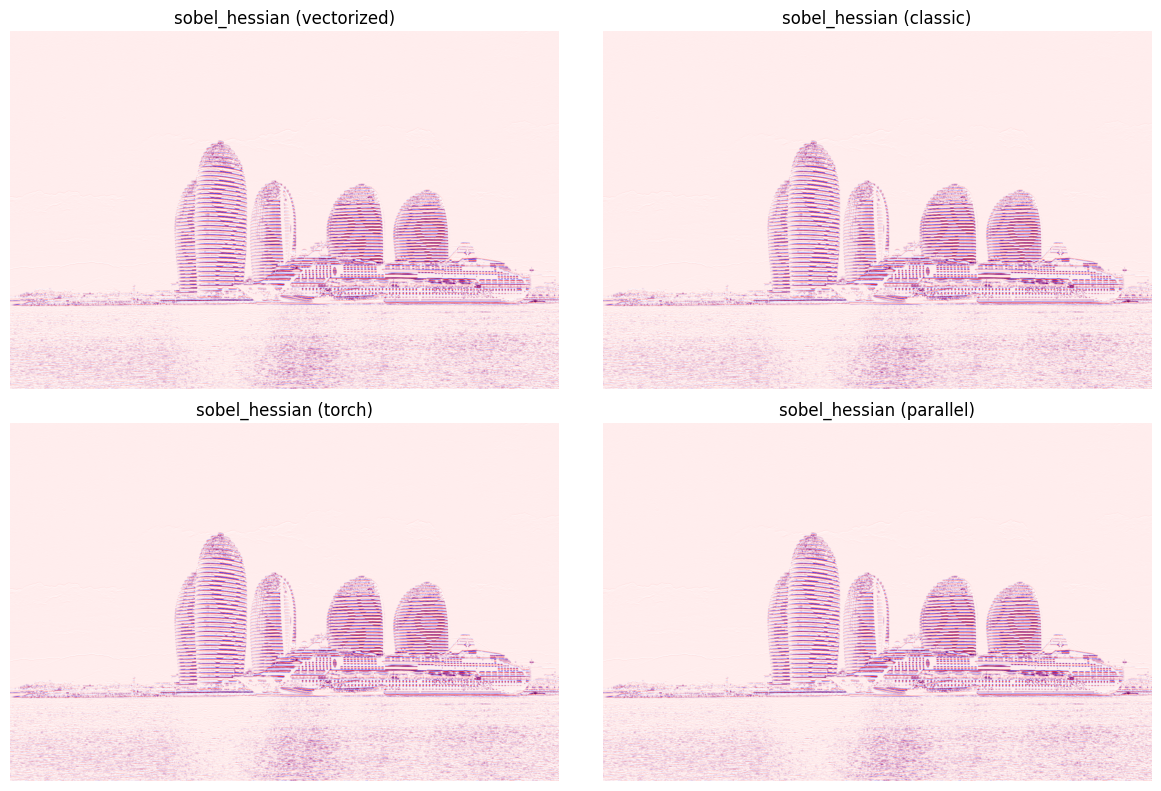

In [21]:
# Visualize 2x2 (Hessian case: select [i,j]=[0,0] if D×D front axes exist)
i, j = 0, 0

def pick_plane(arr):
    # If Hessian-like with (D,D,H,W[,C]), select [i,j] front indices, else return as-is
    if isinstance(arr, np.ndarray) and arr.ndim >= 5 and function_selected.endswith("hessian"):
        return arr[i, j]
    if isinstance(arr, np.ndarray) and arr.ndim >= 4 and function_selected.endswith("gradient"):
        return arr[i]
    return arr

fig, ((a,b),(c,d)) = plt.subplots(2, 2, figsize=(12, 8))

show_plane(a, pick_plane(vectorized_res)[..., 0] if vectorized_res.ndim >= 3 else pick_plane(vectorized_res),
           title=f"{function_selected} (vectorized)", cmap="seismic",)
show_plane(b, pick_plane(classic_res)[..., 0] if classic_res.ndim >= 3 else pick_plane(classic_res),
           title=f"{function_selected} (classic)", cmap="seismic",)
show_plane(c, pick_plane(torch_res)[..., 0] if torch_res.ndim >= 3 else pick_plane(torch_res),
               title=f"{function_selected} (torch)", cmap="seismic",)
show_plane(d, pick_plane(parallel_res)[..., 0] if parallel_res.ndim >= 3 else pick_plane(parallel_res),
           title=f"{function_selected} (parallel)", cmap="seismic")

plt.tight_layout(); plt.show()

## Stats

In [ ]:
# Quick scalar stats to compare strategies
def stats(x):
    arr = x if isinstance(x, np.ndarray) else np.asarray(x)
    return float(arr.mean()), float(arr.std()), float(arr.min()), float(arr.max())

def safe_stats(name, arr, i=0, j=0):
    if arr is None:
        print(f"{name:>16}: n/a"); return
    z = arr[i, j] if (isinstance(arr, np.ndarray) and arr.ndim >= 5 and function_selected.endswith("hessian")) else \
    arr[i] if isinstance(arr, np.ndarray) and arr.ndim >= 4 and function_selected.endswith("gradient") else arr
    m,s,mi,ma = stats(z)
    print(f"{name:>16}: mean={m:.4g} | std={s:.4g} | min={mi:.4g} | max={ma:.4g}")

print(f"—————————————————————————————— {function_selected} stats ————————————————————————————————")
safe_stats("vectorized", vectorized_res)
safe_stats("classic",    classic_res)
safe_stats("torch",      torch_res)
safe_stats("parallel",   parallel_res)

—————————————————————————————— sobel_hessian Stats ————————————————————————————————
      vectorized: mean=-0.001262 | std=38.78 | min=-462 | max=437.8
         classic: mean=-0.001262 | std=38.78 | min=-462 | max=437.8
           torch: mean=-0.001262 | std=38.78 | min=-462 | max=437.8
        parallel: mean=-0.001262 | std=38.78 | min=-462 | max=437.8
